In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("Data/Gender_Data.csv")
df2 = pd.read_csv("Data/data.csv")
data = pd.concat([df1, df2], axis=0)

In [3]:
data.sample(10)

,Name,Gender,Count,Probability
90509,Stylz,M,7.0,1.915720e-08
5973,Chava,F,2750.0,7.526040e-06
83057,Knoxlee,M,11.0,3.010410e-08
124590,Larissa-Jane,F,1.0,2.736740e-09
30093,Anuraadha,1,NaN,NaN
9660,Jenosan,0,NaN,NaN
47679,Ragunashini,1,NaN,NaN
135503,Binhnarit,M,1.0,2.736740e-09
6366,Nino,M,2490.0,6.814480e-06
137839,Giacoma-Gaetano,M,1.0,2.736740e-09


In [4]:
data.drop(columns=['Count','Probability'], inplace=True)
data.sample(10)

,Name,Gender
10783,Pricila,F
92971,Nilufar,F
19314,Joaquina,F
14499,Yohanna,F
17101,Pugal,0
11875,Kowrishankar,0
67523,Rhiannah,F
119637,Dieni,F
116444,Amelia-Holly,F
40101,Kirali,1


In [5]:
data['Gender'].value_counts()

Gender
F    89749
M    57520
0    29014
1    24968
Name: count, dtype: int64

In [6]:
data['Gender'] = data['Gender'].replace({
    0: 'Male',
    1: 'Female',
    'M': 'Male',
    'F': 'Female'
})

data.sample(10)

,Name,Gender
18053,Shaneice,Female
21470,Sundaravel,Male
125739,Mamiko,Female
7951,Jashua,Male
99779,Jelayne,Female
135804,Caan,Male
37051,Isaimurasu,Female
28051,Kristjan,Male
108099,Kyire,Male
63055,Kamariona,Female


In [7]:
data['Gender'].value_counts()

Gender
Female    114717
Male       86534
Name: count, dtype: int64

In [8]:
data.isnull().sum()

Name      0
Gender    0
dtype: int64

In [9]:
len(data['Name'].unique()) == len(data)

False

In [10]:
len(data) - len(data['Name'].unique())

21053

In [11]:
# Identify names with both 'M' and 'F' genders
ambiguous_names = (
    data.groupby('Name')['Gender']
    .nunique()
    .reset_index()
)

ambiguous_names = ambiguous_names[
    ambiguous_names['Gender'] > 1
]['Name']


data.loc[data['Name'].isin(ambiguous_names), 'Gender'] = 'Neutral'

data = data.drop_duplicates(['Name','Gender'])

In [12]:
data['Gender'].unique()

array(['Male', 'Neutral', 'Female'], dtype=object)

In [13]:
data.head()

,Name,Gender
0,Aaban,Male
1,Aabharan,Male
2,Aabhas,Male
3,Aabhat,Male
4,Aabheer,Male


In [14]:
duplicates = data[data.duplicated(subset=['Name', 'Gender'], keep=False)]

print(duplicates)

Empty DataFrame
Columns: [Name, Gender]
Index: []


In [15]:
# Just making this easier to view sorting
data.sort_values(by = "Name", inplace = True)
data.head()

,Name,Gender
112246,A,Neutral
115618,A'Aff,Female
133954,A'Aron,Male
115619,A'Dele,Female
115620,A'Isha,Female


In [16]:
data = data[data['Gender'] != 'Neutral']
data.head()

,Name,Gender
115618,A'Aff,Female
133954,A'Aron,Male
115619,A'Dele,Female
115620,A'Isha,Female
115621,A'Ishah,Female


In [17]:
data['Gender'].value_counts()

Gender
Female    97206
Male      69100
Name: count, dtype: int64

In [18]:
# What unique characters in the names?
characters_unique = set()
cols = ['Name']
for col in cols:
    for value in data[col]:
        for letter in value:
            if letter not in string.ascii_lowercase and letter not in string.ascii_uppercase:
                characters_unique.add(letter)

characters_unique

{'"',
 '&',
 "'",
 '(',
 ')',
 ',',
 '-',
 '.',
 '/',
 '0',
 '1',
 '5',
 '7',
 '8',
 '9',
 ';',
 '?',
 '@',
 '[',
 '¡',
 'à',
 'ö',
 'œ',
 '…'}

In [19]:
import re
import unicodedata
def clean_name(name):
    # Convert to string
    name = str(name)

    # Normalize unicode (é → e, ö → o)
    name = unicodedata.normalize('NFKD', name)

    # Encode to ASCII (ignore non-ascii parts)
    name = name.encode('ascii', 'ignore').decode('utf-8')

    # Keep only alphabets
    name = re.sub(r'[^a-zA-Z]', '', name)

    return name.lower()

In [20]:
data['Name'] = data['Name'].apply(clean_name)
data.head()

,Name,Gender
115618,aaff,Female
133954,aaron,Male
115619,adele,Female
115620,aisha,Female
115621,aishah,Female


In [21]:
data.isnull().sum()

Name      0
Gender    0
dtype: int64

In [22]:
import string

characters_unique = set()

cols = ['Name']

for col in cols:
    for value in data[col]:
        value = str(value)  # handle NaN or non-string
        for letter in value:
            if letter not in string.ascii_letters:
                characters_unique.add(letter)

characters_unique

set()

In [23]:
min_len = data['Name'].astype(str).apply(len).min()
max_len = data['Name'].astype(str).apply(len).max()

print("Minimum Name Length:", min_len)
print("Maximum Name Length:", max_len)

Minimum Name Length: 1
Maximum Name Length: 24


In [24]:
data['name_len'] = data['Name'].astype(str).str.len()

print(data['name_len'].describe())

count    166306.000000
mean          7.292984
std           1.961040
min           1.000000
25%           6.000000
50%           7.000000
75%           8.000000
max          24.000000
Name: name_len, dtype: float64


In [25]:
min_len = data['Name'].astype(str).apply(len).min()
max_len = data['Name'].astype(str).apply(len).max()

print("Minimum Name Length:", min_len)
print("Maximum Name Length:", max_len)

Minimum Name Length: 1
Maximum Name Length: 24


In [29]:
data = data[data['Name'].notna()]
data['Name'] = data['Name'].str.strip()
data = data[
    (data['Name'].str.len() >= 2) &
    (data['Name'].str.len() < 20)
]

In [30]:
print(data['Gender'].value_counts())

Gender
Female    96192
Male      68828
Name: count, dtype: int64


In [31]:
data = data.drop_duplicates().reset_index(drop=True)

In [32]:
data.isnull().sum()

Name        0
Gender      0
name_len    0
dtype: int64

In [33]:
data.duplicated(subset=['Name', 'Gender']).sum()

np.int64(0)

In [35]:
data['name_len'].skew()

np.float64(0.9181557054047548)

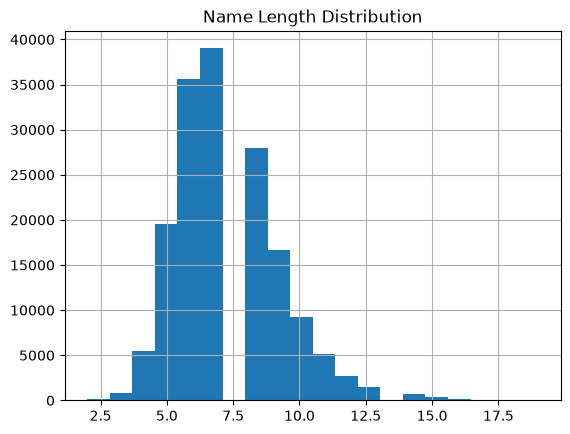

In [36]:
import matplotlib.pyplot as plt

data['name_len'].hist(bins=20)
plt.title("Name Length Distribution")
plt.show()

In [37]:
data['Gender'].value_counts()

Gender
Female    96192
Male      68828
Name: count, dtype: int64

In [38]:
gender_percent = data['Gender'].value_counts(normalize=True) * 100
print(gender_percent)

Gender
Female    58.291116
Male      41.708884
Name: proportion, dtype: float64


In [39]:
data.drop(columns=['name_len'], inplace=True)
data.head()

,Name,Gender
0,aaff,Female
1,aaron,Male
2,adele,Female
3,aisha,Female
4,aishah,Female


In [40]:
# Text Normalization
data['Name'] = data['Name'].astype(str).str.strip().str.lower()

In [41]:
# Features and target
X = data['Name']
y = data['Gender']

In [42]:
# Character TF-IDF
vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
)
X=vectorizer.fit_transform(data['Name'])

In [43]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

In [46]:
model = LogisticRegression(
    C=3,
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced'
)
model.fit(x_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",3
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomi

In [47]:
y_pred = model.predict(x_test)
y_train_pred = model.predict(x_train)
# Results
print("Test Data Accuracy:", accuracy_score(y_test, y_pred))
print("Train Data Accuracy: ", accuracy_score(y_train, y_train_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Data Accuracy: 0.8909829111622833
Train Data Accuracy:  0.9461656162889347

Classification Report:

              precision    recall  f1-score   support

      Female       0.92      0.89      0.91     19238
        Male       0.86      0.89      0.87     13766

    accuracy                           0.89     33004
   macro avg       0.89      0.89      0.89     33004
weighted avg       0.89      0.89      0.89     33004



In [50]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[17167  2071]
 [ 1527 12239]]


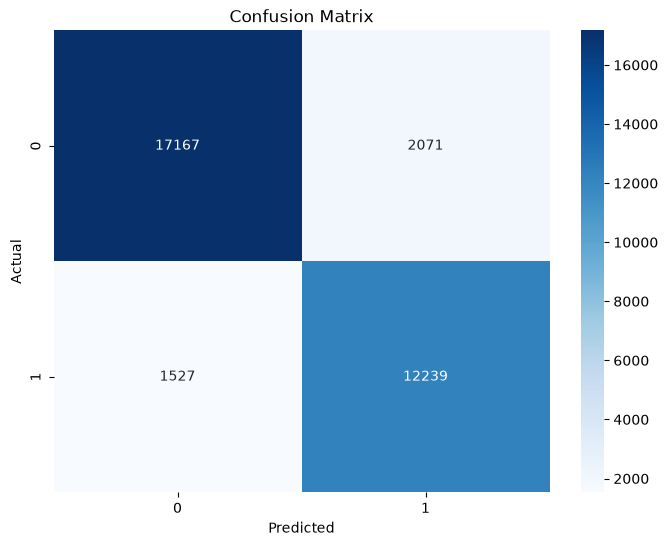

In [51]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [52]:
import joblib
import os

# create folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# save files
joblib.dump(vectorizer, "models/vectorizer.pkl")
joblib.dump(model, "models/gender_model.pkl")

['models/gender_model.pkl']